<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Flexão de vigas constituídas por vários materiais.

### Problema 3

Considere a viga com a secção transversal em H indicada na figura, fabricada em aço com módulo de Young, $E$(aço) = 210 GPa e tensão admissível $\sigma_\textrm{adm}$ (aço) = 235 MPa. Para a reforçar foi colocada uma tábua de carvalho entre as duas abas, como é representado. Sabendo que para a madeira de carvalho, o módulo de Young vale $E$(madeira)= 12 GPa e a tensão admissível é igual a $\sigma_\textrm{adm}$ (madeira) = 21 MPa , determine o valor do momento fletor máximo que pode ser aplicado sobre a secção composta em redor do eixo $y$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au02/P3/MSII_Au02_P3.png"
width="1200" />

### Resolução

Para iniciar a resolução do problema, deve-se propor uma secção homogénea, composta por um único material, que seja equivalente à secção composta original em termos de deflexão, para o mesmo momento fletor aplicado.

A análise deve ser realizada em relação ao eixo $y$. Por isso, a secção transformada pode ser obtida de forma conveniente ao reduzir a viga de madeira ao longo do comprimento da base de 225 mm, mantendo a simetria do problema, conforme ilustrado a seguir

tot length : 200.0 mm
tot height : 250.0 mm
 Wood section : 93.8 mm x 12.5 mm = 21093.8 mm²
Steel section : 5312.5   mm²


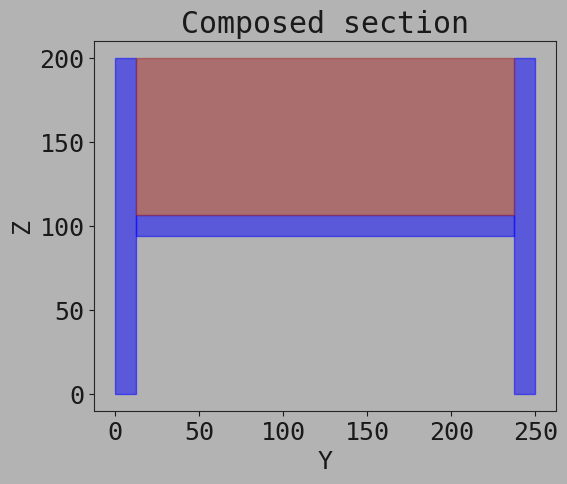

In [13]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: SI: kN, m
class varin: pass
Wood = varin()  # Create an empty class
Steel = varin()
S = varin()

# units: N, m, Pa
Wood.E = 12e3 # MPa
Wood.Sadm = 21 # MPa
Steel.E = 210e3 # MPa
Steel.Sadm = 235 # MPa

S.dz1 = 93.75 # mm
S.dz2 = 12.5 # mm
S.dzt = 2*S.dz1+S.dz2
print(f'tot length : {S.dzt:.1f} mm')

S.dy1 = 12.5 # mm
S.dy2 = 225 # mm
S.dyt = 2*S.dy1+S.dy2
print(f'tot height : {S.dyt:.1f} mm')

S.Aw = S.dz1*S.dy2
print(f' Wood section : {S.dz1:.1f} mm x {S.dz2:.1f} mm = {S.Aw:.1f} mm²')

S.As = S.dzt*S.dy1 + S.dz2*S.dy2
print(f'Steel section : {S.As:.1f}   mm²')

from matplotlib.patches import Rectangle

fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.add_patch(Rectangle((0, 0),S.dy1,S.dzt,color="blue",alpha=0.5))
ax.add_patch(Rectangle((S.dy1,(S.dzt-S.dz2)/2),S.dy2,S.dz2,color="blue",alpha=0.5))
ax.add_patch(Rectangle((S.dy1+S.dy2,0),S.dy1,S.dzt,color="blue",alpha=0.5))
ax.add_patch(Rectangle((S.dz2,(S.dy2-S.dy1)/2),S.dy2,S.dz1,color="brown",alpha=0.5))
plt.xlabel("Y")
plt.ylabel("Z")
plt.title("Composed section")
ax.set_aspect('equal')
plt.show()

### Secção transversal homogénea de aço

A transformação da região de madeira em aço pode ser obtida usando o seguinte rácio material:

\begin{equation*}
n = \frac{E_\mathrm{w}}{E_\mathrm{s}}
\end{equation*}

n = Es/Ew = 0.057 
lw2s = n*lw = 12.857 


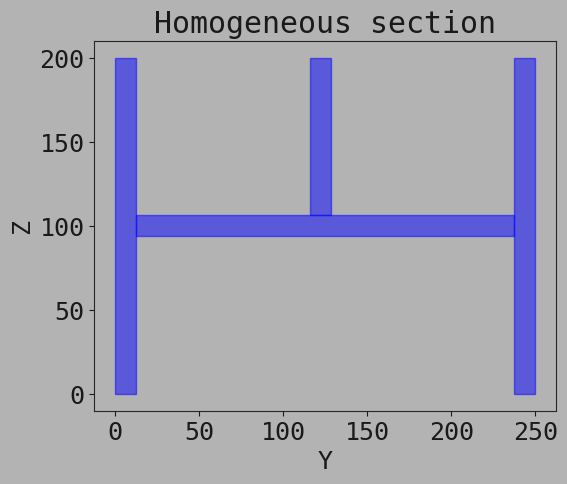

In [14]:
S.n = Wood.E/Steel.E
print(f'n = Es/Ew = {S.n:.3f} ')

print(f'lw2s = n*lw = {S.n*S.dy2:.3f} ')

fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.add_patch(Rectangle((0, 0),S.dy1,S.dzt,color="blue",alpha=0.5))
ax.add_patch(Rectangle((S.dy1,(S.dzt-S.dz2)/2),S.dy2,S.dz2,color="blue",alpha=0.5))
ax.add_patch(Rectangle((S.dy1+S.dy2,0),S.dy1,S.dzt,color="blue",alpha=0.5))
ax.add_patch(Rectangle((S.dz2+S.dz1*1.1,(S.dy2-S.dy1)/2),S.dy2*S.n,S.dz1,color="blue",alpha=0.5))
plt.xlabel("Y")
plt.ylabel("Z")
plt.title("Homogeneous section")
ax.set_aspect('equal')
plt.show()

#### Centroíde da secção

A secção homogénea equivalente tem apenas um plano de simetria que conduz a : $\overline{y} = 0$.

A coordenada em $z$ do centroíde de secção pode ser obtido pela equivalência do segundo momento de área:

\begin{equation*}
\overline{z} = \sum_i \frac{A_i\overline{z}_i}{A_i}
\quad\Rightarrow\quad
\overline{z} = \frac{\sum_{i=1}^{2} A_\textrm{i}\overline{z}_\textrm{i}\Big|_\textrm{st} + n A_\textrm{w}\overline{z}_\textrm{w}}{\sum_{i=1}^{2} A_\textrm{i}\Big|_\textrm{st} + n A_\textrm{w}}
\end{equation*}

Considere-se um referêncial auxilar na base inferior esquerda do perfil.

In [15]:
print('::::::::::::::::::::::::::::::')
S.Rz1 = S.dzt/2
print(f'S.Rz1 = {S.dzt}/2 = {S.Rz1:.2f} mm')
S.RA1 = S.dzt*S.dy1
print(f'S.RA1 = {S.dzt}({S.dy1})  = {S.RA1:.2f} mm²')
print(f'S.Rz1*S.Rz1 = {S.Rz1*S.RA1:.2f} mm³')

::::::::::::::::::::::::::::::
S.Rz1 = 200.0/2 = 100.00 mm
S.RA1 = 200.0(12.5)  = 2500.00 mm²
S.Rz1*S.Rz1 = 250000.00 mm³


In [16]:
print('::::::::::::::::::::::::::::::')
S.Rz2 = S.dzt/2
print(f'S.Rz2 = {S.dzt}/2 = {S.Rz2:.2f} mm')
S.RA2 = S.dz2*S.dy2
print(f'S.RA2 = {S.dz2}({S.dy2}) = {S.RA2:.2f} mm²')
print(f'S.Rz2*S.RA2 = {S.Rz2*S.RA2:.2f} mm³')

::::::::::::::::::::::::::::::
S.Rz2 = 200.0/2 = 100.00 mm
S.RA2 = 12.5(225) = 2812.50 mm²
S.Rz2*S.RA2 = 281250.00 mm³


In [17]:
print(': (transformed) ::::::::::::::')
S.Rz3 = S.dz1+S.dz2+S.dz1/2
print(f'S.Rz3 = ({S.dz1})({S.dz2})({S.dz1}/2) = {S.Rz3:.2f} mm')
S.RA3 = S.n*S.dz1*S.dy2
print(f'S.RA3 = ({S.n:.2f})({S.dz1})({S.dy2}) = {S.RA3:.2f} mm²')
print(f'S.Rz3*S.RA3 = {S.Rz3*S.RA3:.2f} mm³')

: (transformed) ::::::::::::::
S.Rz3 = (93.75)(12.5)(93.75/2) = 153.12 mm
S.RA3 = (0.06)(93.75)(225) = 1205.36 mm²
S.Rz3*S.RA3 = 184570.31 mm³


In [18]:
print('::::::::::::::::::::::::::::::')
numer = 2*S.Rz1*S.RA1 + S.Rz2*S.RA2 + S.Rz3*S.RA3
denom = 2*S.RA1+S.RA2+S.RA3
S.ztot = numer/denom
print(f'y transformed section = {numer:.1f}/{denom:.1f} = {S.ztot:.2f} mm')

::::::::::::::::::::::::::::::
y transformed section = 965820.3/9017.9 = 107.10 mm


#### Segundo momento de área da secção 

O momento de inércia da secção transformada pode também ser obtido pela combinação linear dos momentos de inércia das regiões elementares da secção:

\begin{equation*}
I_{y}^\textrm{total} = \sum_{i=1}^{2}I_\textrm{i}\Big|_{\textrm{st}} + nI_\textrm{w} = 2(\underbrace{\overline{I}_1 + A_1 d_1²}_{\textrm{st 1}}) + \underbrace{n(\overline{I}_2+A_2 d_2²)}_{\textrm{w}}
+ \underbrace{\overline{I}_3 + A_3 d_3²}_{\textrm{st 2}}
\end{equation*}

In [19]:
def irect(b,h):
    return b*h**3/12

print('::::::::::::::::::::::::::::::')
d1 = S.ztot - S.Rz1
print(f'd1    = {S.ztot:.1f} - {S.Rz1:.1f} = {d1:.2f} mm')
Ic1 = irect(S.dy1,S.dzt)
print(f'Ic.s2 = {Ic1:.2f} mm⁴')
S.Is1 = Ic1 + S.RA1*d1**2
print(f'S.Is1 = {Ic1:.1f} + ({S.RA1:.1f})({d1:.1f})**2 = {S.Is1:.2f} mm⁴')

::::::::::::::::::::::::::::::
d1    = 107.1 - 100.0 = 7.10 mm
Ic.s2 = 8333333.33 mm⁴
S.Is1 = 8333333.3 + (2500.0)(7.1)**2 = 8459389.09 mm⁴


In [20]:
print('::::::::::::::::::::::::::::::')
d2 = S.ztot - S.Rz2
print(f'd2    = {S.ztot:.1f} - {S.Rz2:.1f} =  {d2:.2f} mm')
Ic2 = irect(S.dy2,S.dz2)
print(f'Ic.s2 = {Ic2:.2f} mm⁴')
S.Is2 = Ic2 + S.RA2*d2**2
print(f'S.Is2 = {Ic2:.1f} + ({S.RA2:.1f})({d2:.1f})**2 = {S.Is2:.2f} mm⁴')

::::::::::::::::::::::::::::::
d2    = 107.1 - 100.0 =  7.10 mm
Ic.s2 = 36621.09 mm⁴
S.Is2 = 36621.1 + (2812.5)(7.1)**2 = 178433.82 mm⁴


In [21]:
print(': (transformed) ::::::::::::::')
d3 = S.Rz3 - S.ztot
print(f'd3   = {S.Rz3:.2f} - {S.ztot:.2f} = {d3:.2f} mm')
S.Iw = irect(S.dy2*S.n,S.dz1) + S.RA3*d3**2
print(f'S.Iw = {irect(S.dy2*S.n,S.dz1):.1f} + ({S.RA3:.1f})({d3:.1f})**2 = {S.Iw:.2f} mm⁴')

: (transformed) ::::::::::::::
d3   = 153.12 - 107.10 = 46.02 mm
S.Iw = 882829.9 + (1205.4)(46.0)**2 = 3436042.61 mm⁴


In [22]:
print('::::::::::::::::::::::::::::::')
S.Itot = 2*S.Is1 + S.Iw + S.Is2
print(f'S.Itot = {2*S.Is1:.2f} + {S.Iw:.2f} + {S.Is2:.2f} = {S.Itot:.2f} mm⁴')

::::::::::::::::::::::::::::::
S.Itot = 16918778.18 + 3436042.61 + 178433.82 = 20533254.61 mm⁴


Avaliando agora o valor do momento fletor máximo que pode ser aplicado sobre a secção composta em torno do eixo $y$, considerando o nível de tensão aplicado, devido à flexão, em cada ponto crítico:

- Aço:

\begin{equation*}
\sigma_\mathrm{adm} \geq \left| \frac{M_y}{I_y}z \right|
\end{equation*}

- Madeira:

\begin{equation*}
\sigma_\mathrm{adm} \geq \left| n\left(\frac{M_y}{I_y}z\right) \right|
\end{equation*}


In [23]:
import sympy as sy

mf1, mf2 = sy.symbols('mf1 mf2')

print(': steel :::::::::::::::::::::::::::::')
y1_stell = S.ztot
print(f'|ysteel| = {y1_stell:.2f} mm')
EQ1 = Steel.Sadm - mf1*y1_stell/S.Itot
print(f'dim.EQ1 = {EQ1}')
sol = sy.solve(EQ1,mf1)
M1 = sol[0]
print(f'Mf Steel = {M1:.1f} N.mm = {M1*1e-3:.1f} kN.mm = {M1*1e-6:.1f} kN.m ')

: steel :::::::::::::::::::::::::::::
|ysteel| = 107.10 mm
dim.EQ1 = 235 - 5.21597128122262e-6*mf1
Mf Steel = 45053929.0 N.mm = 45053.9 kN.mm = 45.1 kN.m 


In [24]:
print(': wood :::::::::::::::::::::::::::::')
y1_swood = S.dzt - S.ztot
print(f'|ywood| = {y1_swood:.2f} mm')
EQ2 = Wood.Sadm - mf2*y1_swood/S.Itot*S.n
print(f'dim.EQ2 = {EQ2}')
sol = sy.solve(EQ2,mf2)
M2 = sol[0]
print(f'Mf wood = {M2:.1f} N.mm = {M2*1e-3:.1f} kN.mm = {M2*1e-6:.1f} kN.m ')

: wood :::::::::::::::::::::::::::::
|ywood| = 92.90 mm
dim.EQ2 = 21 - 2.58532903107586e-7*mf2
Mf wood = 81227572.0 N.mm = 81227.6 kN.mm = 81.2 kN.m 


---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>